In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from typing import Union, List, Dict, Optional

In [46]:
# store reference data (MW, density)
Material_Dictionary_Rawdata = {
    "MW" : [337.33, 105.99, 120.336, 131.7, 353.4, 353.4,  204.23, 426.46, 89.09, 311.33, 131.17, 337.37, 157.62, 343.4, 18.01, 88.11, 84.93,86.18, 36.46, 60.08, 119.37, 32.04, 60.05, 131.7, 204.23, 89.09, 131.17, 121.16],
    "Density" : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1000, 1033, 1325, 660, 1010, 0, 1489.2, 792, 1040, 0, 0, 0, 0, 0]
}

Material_dictionary = pd.DataFrame(Material_Dictionary_Rawdata, index = ['Fmoc-OSU', 'Na2CO3', 'MgSO4', 'Leu', 'Fmoc-L-Leu', 'Fmoc-D-Leu', 'Trp', 'Fmoc-Trp', 'Ala', 'Fmoc-L-Ala', 'Pro', 'Fmoc-Pro', 'Cys.HCl', 'Fmoc-Cys', 'H2O', 'Dioxane', 'DCM', 'Hexane', 'HCl', 'Silica', 'Chlorofom', 'MeOH', 'Acetic acid', 'Leu', 'Trp', 'Ala', 'Pro', 'Cys'])
print(Material_dictionary.head())

                 MW  Density
Fmoc-OSU    337.330      0.0
Na2CO3      105.990      0.0
MgSO4       120.336      0.0
Leu         131.700      0.0
Fmoc-L-Leu  353.400      0.0


In [ ]:
# Consumption data
Material_Consumption_url = 'https://github.com/FairzanIsLearning/OralLeptinExploration/blob/main/Material_Consumption.csv?raw=true'
Material_consumption_rawdata = pd.read_csv(Material_Consumption_url)
# materials are in mg and solvents are in mL
# Define metadata in the file
metadata = ['No', 'Code', 'Name', 'Purification duration', 'Total purification solvent', 'Purification Solvent B']
material_cols = [col for col in Material_consumption_rawdata.columns if col not in metadata]

#print(Material_consumption_rawdata.head())

In [ ]:
# Define material type and whats used in each stage

# Define material type
Raw_material = ['AA', 'Fmoc']
Solvent = ['H2O', 'Dioxane', 'DCM', 'Hexane', 'Chloroform', 'MeOH', 'Acetic acid']
Auxillary = ['Silica', 'MgSO4']
Reagent = ['HCl', 'Na2CO3']

# Define materials for each stage
Prepurification_material = ['Dioxane', 'Na2CO3', 'MgSO4', 'Silica sample', 'Hexane', 'HCl', 'DCM extraction']
Purification_material = ['Chloroform', 'Acetic acid', 'MeOH', 'Silica col', 'DCM purification']

In [ ]:
# Helper functions to extract data from the dataframe reference

# get MW
def _get_mw(compound: str) -> float:
    """Retrieve molecular weight (g/mol) from dataframe."""
    df : Material_dictionary
    if compound in df.index:
        mw = df.loc[compound, 'MW']
    elif 'name' in df.columns:
        row = df[df['name'] == compound]
        if row.empty:
            raise KeyError(f"Compound '{compound}' not found in dataframe (index or 'name' column).")
        mw = row.iloc[0]['MW']
    else:
        raise KeyError(f"Compound '{compound}' not in index and no 'name' column.")
    if mw <= 0:
        raise ValueError(f"Molecular weight for {compound} is {mw} (must be > 0).")
    return mw

# get density
def _get_density(compound: str) -> float:
    """Retrieve density (g/mL) from dataframe. Raises error if missing."""
    df : Material_dictionary
    if compound in df.index:
        dens = df.loc[compound, 'density']
    elif 'name' in df.columns:
        row = df[df['name'] == compound]
        if row.empty:
            raise KeyError(f"Compound '{compound}' not found for density lookup.")
        dens = row.iloc[0]['density']
    else:
        raise KeyError(f"Cannot find density for '{compound}': no index or 'name' column.")
    if pd.isna(dens):
        raise ValueError(f"Density for {compound} is missing (NaN). Provide density in dataframe.")
    if dens <= 0:
        raise ValueError(f"Density for {compound} is {dens} (must be > 0).")
    return dens

# get mass from volume
def _mass_from_volume(compound: str, volume: float) -> float:
    df : Material_dictionary
    """Convert volume (mL) to mass (g) using density from dataframe."""
    density = _get_density(compound, df)
    return volume * density

# prioritize volume over mass if they are co exist
def _resolve_masses(compound_names: List[str],
                    masses: Optional[Dict[str, float]],
                    volumes: Optional[Dict[str, float]]) -> Dict[str, float]:
    """
    Combine explicit masses and volumes into a single mass dictionary.
    Volume takes precedence over mass if both are given for the same compound.
    """
    df : Material_dictionary
    result = {}
    if masses:
        result.update(masses)
    if volumes:
        for cmp, vol in volumes.items():
            result[cmp] = _mass_from_volume(cmp, vol, df)
    # Check that all required compounds have a mass
    missing = set(compound_names) - set(result.keys())
    if missing:
        raise ValueError(f"Missing mass or volume for compounds: {missing}")
    return result

In [19]:
# Function to add solvent weight from its volume based on the density
def add_solvent_weights(df_consumption, density_df, weight_func):
    """
    Add weight columns for all solvents present in df_consumption.

    For each column in df_consumption whose name matches an index entry in
    density_df, create a new column '{col}_weight' by applying weight_func
    to the volume values (assumed to be in mL). Non‑numeric or missing volumes
    result in NaN in the weight column.

    Parameters
    ----------
    df_consumption : pd.DataFrame
        The material consumption DataFrame containing solvent volumes.
    density_df : pd.DataFrame
        DataFrame with solvent names as index. Used to identify which columns
        are solvents. Your weight_func may also use it internally.
    weight_func : callable
        Function that takes (solvent_name, volume_ml) and returns the weight.
        Example: def weight_func(name, vol): return vol * density_df.loc[name, 'density']

    Returns
    -------
    pd.DataFrame
        Original DataFrame with additional weight columns.
    """
    # Make a copy to avoid modifying original data unintentionally
    df = df_consumption.copy()
    
    # Identify solvent columns: those present in the density_df index
    solvent_cols = [col for col in df.columns if col in density_df.index]
    
    for solvent in solvent_cols:
        weight_col = f"{solvent}_weight"
        # Apply weight_func row by row; skip non-numeric values
        df[weight_col] = df[solvent].apply(
            lambda vol: weight_func(solvent, vol) if pd.notna(vol) and isinstance(vol, (int, float)) else np.nan
        )
    
    return df


In [ ]:
# function to calculate the green metrics

# Yield (y)
# Atom economy (AE)
# Stoichiometric factor (SF)
# Processing mass intensity (PMI)
# Mass productivity (MP)
# Solvent intensity (SI)
# Reaction mass efficiency (RME)
# Green Atomic level
# Effective mass yield (YME)
# Environmental impact factor (EFactor)

In [56]:
# Green Chemistry Metrics Calculation functions
# Based on DOI: 10.1039/C4GC01563K, 10.1039/d3gc03918h, 10.1002/cite.202300229

# 1. Atom Economy (AE)
def atom_economy(product_name: str,
                 reactants: Union[Dict[str, float], List[tuple]],
                 df_compounds: pd.DataFrame) -> float:
    """
    AE measures the inherent efficiency of a reaction, showing how much of the reactant atoms end up in the desired product.
    Formula: AE = (Sum of MWs of desired product(s)) / (Sum of MWs of all reactants) * 100
    Best if it close to 100
    Parameters
        product_name [str] : Name of the desired product (must match index or 'name' column in df_compounds).
        reactants : [dict] : {reactant_name: stoichiometric coefficient} for all reactants in the balanced equation.
    Returns
        float : Atom economy in percent (0-100).
    Raises
        KeyError : If any compound (product or reactant) is not found in the dataframe.
        ValueError : If molecular weights are missing or zero/negative.
    """
    # Convert list of tuples to dict
    if isinstance(reactants, list):
        reactants = dict(reactants)

    # Determine product list
    if product_names is None:
        prod_list = [product_name]
    elif isinstance(product_names, str):
        prod_list = [product_names]
    else:
        prod_list = product_names

    # Helper to get MW as a scalar
    def get_mw(compound: str) -> float:
        if compound in df_compounds.index:
            val = df_compounds.loc[compound, 'MW']
        elif 'name' in df_compounds.columns:
            row = df_compounds[df_compounds['name'] == compound]
            if row.empty:
                raise KeyError(f"Compound '{compound}' not found.")
            val = row.iloc[0]['MW']
        else:
            raise KeyError(f"No index or 'name' column for '{compound}'.")
        # Ensure val is a scalar (not a Series)
        if hasattr(val, 'iloc'):
            val = val.iloc[0]
        if pd.isna(val) or val <= 0:
            raise ValueError(f"Invalid MW for {compound}: {val}")
        return float(val)

    total_prod_mw = sum(get_mw(p) for p in prod_list)
    total_react_mw = sum(get_mw(r) * coeff for r, coeff in reactants.items())
    if total_react_mw == 0:
        raise ValueError("Total reactant MW is zero.")
    return (total_prod_mw / total_react_mw) * 100.0

# 2. Stoichiometric Factor (SF)
def stoichiometric_factor(actual_masses: Optional[Dict[str, float]] = None,
                          actual_volumes: Optional[Dict[str, float]] = None,
                          stoichiometry: Optional[Dict[str, float]] = None,
                          limiting_reactant: Optional[str] = None) -> float:
    """
    Calculate the Stoichiometric Factor (SF) as defined in the provided image:

        SF = 1 + (Total mass of excess reagents) / (Total stoichiometric mass of reagents) × 100%

    where the ratio (excess / stoichiometric) is multiplied by 100% (i.e., by 1),
    so SF = 1 + (excess / stoichiometric) = total_actual / stoichiometric.

    Parameters
    ----------
    actual_masses : dict, optional
        {reactant_name: mass_in_grams} for each reactant.
    actual_volumes : dict, optional
        {reactant_name: volume_in_mL} (density required in df_compounds).
    stoichiometry : dict, optional
        {reactant_name: stoichiometric_coefficient} in the balanced equation.
    df_compounds : pd.DataFrame
        Must contain 'MW' (g/mol) and optionally 'density' (g/mL).
    limiting_reactant : str, optional
        Name of the limiting reactant (if None, determined automatically).

    Returns
    -------
    float
        Stoichiometric factor (≥ 1.0). For example, 1.5 means 1 + 50%.
    """
    if stoichiometry is None:
        raise ValueError("stoichiometry dict required: {reactant: coefficient}")
    reactants = list(stoichiometry.keys())

    # Convert volumes to masses if needed
    effective_masses = _resolve_masses(reactants, actual_masses, actual_volumes, df_compounds)

    # Get MWs and calculate moles
    mw_dict = {r: _get_mw(r, Material_dictionary) for r in reactants}
    actual_moles = {r: effective_masses[r] / mw_dict[r] for r in reactants}

    # Determine limiting reactant if not specified
    if limiting_reactant is None:
        ratios = {r: actual_moles[r] / stoichiometry[r] for r in reactants}
        limiting_reactant = min(ratios, key=ratios.get)
    else:
        if limiting_reactant not in reactants:
            raise ValueError(f"Limiting reactant '{limiting_reactant}' not in stoichiometry")

    # Calculate theoretical (stoichiometric) masses based on limiting reactant
    limiting_coeff = stoichiometry[limiting_reactant]
    limiting_moles = actual_moles[limiting_reactant]

    stoichiometric_mass = 0.0
    for r in reactants:
        required_moles = (stoichiometry[r] / limiting_coeff) * limiting_moles
        stoichiometric_mass += required_moles * mw_dict[r]

    total_actual_mass = sum(effective_masses.values())

    if stoichiometric_mass <= 0:
        raise ValueError("Stoichiometric mass cannot be zero or negative.")

    excess_mass = total_actual_mass - stoichiometric_mass
    if excess_mass < 0:
        # This should not happen if limiting reactant is correctly identified
        # but can occur due to rounding; clamp to zero.
        excess_mass = 0.0

    # SF = 1 + (excess_mass / stoichiometric_mass)   [the ×100% is implicit]
    sf = 1.0 + (excess_mass / stoichiometric_mass)
    return sf

# 3. Process Mass Intensity (PMI)
def process_mass_intensity(total_mass_input: float,
                           mass_product: float,
                           include_water: bool = True) -> float:
    """
    PMI = total mass of materials used in a process (including water) / mass of final product

    Parameters:
        total_mass_input : Sum of all raw materials, reagents, solvents, water, etc.
        mass_product : Mass of isolated desired product.
        include_water : If False, water mass is excluded (default True).
    Returns:
        float: Process Mass Intensity (kg input / kg product).
    Raises
        ValueError : If molecular weights are missing or zero/negative.
    """
    if mass_product <= 0:
        raise ValueError("Product mass must be positive.")
    if total_mass_input < 0:
        raise ValueError("Total input mass cannot be negative.")
    return total_mass_input / mass_product

# 4. Mass Productivity (MP)
def mass_productivity(total_mass_input: float,
                      mass_product: float,
                      include_water: bool = True) -> float:
    """
    Formula: MP = (mass product / total mass input) * 100

    Parameters:
        total_mass_input : Sum of all materials used in the process.
        mass_product : Mass of isolated product.
        include_water : If False, water mass is excluded from total (default True).
    Returns:
        float: Mass Productivity in percent (0-100).
    """
    pmi = process_mass_intensity(total_mass_input, mass_product, include_water)
    return (1.0 / pmi) * 100.0

# 5. Solvent Intensity (SI)
def solvent_intensity(mass_solvents: float,
                      mass_product: float,
                      include_water: bool = False) -> float:
    """
    SI = total mass of solvents (and optionally water) used / mass of product

    Parameters:
        mass_solvents : Total mass of all solvents used (including any aqueous workup).
        mass_product : Mass of isolated product.
        include_water : If True, the mass of water is included in the solvent mass.
    Returns:
        float: Solvent Intensity (kg solvent / kg product).
    Raises
        ValueError : If molecular weights are missing or zero/negative.
    """
    if mass_product <= 0:
        raise ValueError("Product mass must be positive.")
    if mass_solvents < 0:
        raise ValueError("Solvent mass cannot be negative.")
    return mass_solvents / mass_product

# 6. Reaction Mass Efficiency (RME)
def reaction_mass_efficiency(mass_product: float,
                             total_reactant_mass: float,
                             include_workup_materials: bool = False,
                             extra_material_mass: float = 0.0) -> float:
    """
    RME = (mass of product) / (total mass of all reactants) * 100
    Optionally, one can include workup materials as well.
    Formula: RME = mass product / (total reactants + workup materials) * 100

    Parameters:
        mass_product : Mass of isolated desired product.
        total_reactant_mass : Sum of masses of all reactants used (including any excess).
        include_workup_materials : If True, extra work‑up materials are added.
        extra_material_mass : Additional mass (catalysts, workup solvents etc.) when include_workup_materials is True.
    Returns:
        float: Reaction Mass Efficiency in percent (0-100).
    Raises
        ValueError : If molecular weights are missing or zero/negative.
    """
    if mass_product <= 0:
        raise ValueError("Product mass must be positive.")
    denominator = total_reactant_mass + (extra_material_mass if include_workup_materials else 0)
    if denominator <= 0:
        raise ValueError("Total mass of reactants cannot be zero.")
    return (mass_product / denominator) * 100.0

# 7. Green Atomic Level (GAL) 
def green_atomic_level(product_name: str,
                       reactants: Dict[str, float],
                       actual_masses: Optional[Dict[str, float]] = None,
                       actual_volumes: Optional[Dict[str, float]] = None,
                       product_mass: Optional[float] = None,
                       product_volume: Optional[float] = None,
                       df_compounds: pd.DataFrame = None) -> float:
    """
    GAL = Reaction Mass Efficiency (as fraction) / Atom Economy (as fraction)
        = (RME_%) / (AE_%)

    Parameters
    ----------
    product_name : str
        Name of the desired product (must be in df_compounds).
    reactants : dict
        {reactant_name: stoichiometric coefficient} for the balanced reaction.
    actual_masses : dict, optional
        {reactant_name: mass_used_in_grams} for each reactant.
    actual_volumes : dict, optional
        {reactant_name: volume_used_in_mL} (requires density in df_compounds).
    product_mass : float, optional
        Actual isolated mass of product (in grams).
    product_volume : float, optional
        Volume of product isolated (mL) — used if product_mass not given.
    df_compounds : pd.DataFrame
        Must contain 'MW' and optionally 'density' for volume conversion.

    Returns
    -------
    float
        Green Atomic Level (dimensionless, typically between 0 and 1).
    Raises
        ValueError : If molecular weights are missing or zero/negative.
    """
    # Atom Economy returns percent (0-100)
    ae_percent = atom_economy(product_name, reactants, df_compounds)

    # Reaction Mass Efficiency returns percent (0-100)
    rme_percent = reaction_mass_efficiency(
        product_mass=product_mass,
        product_volume=product_volume,
        product_name=product_name,
        reactant_masses=actual_masses,
        reactant_volumes=actual_volumes,
        reactants_list=list(reactants.keys()),
    )

    if ae_percent == 0:
        raise ValueError("Atom Economy is zero; cannot compute GAL.")

    # Ratio of the two fractions (percent cancels)
    gal = rme_percent / ae_percent
    return gal

# 8. Effective Mass Yield (EMY)
def effective_mass_yield(product_mass: Optional[float] = None,
                         product_volume: Optional[float] = None,
                         product_name: Optional[str] = None,
                         raw_materials_masses: Optional[Dict[str, float]] = None,
                         raw_materials_volumes: Optional[Dict[str, float]] = None,
                         reagents_masses: Optional[Dict[str, float]] = None,
                         reagents_volumes: Optional[Dict[str, float]] = None,
                         df_compounds: pd.DataFrame = None) -> float:
    """
    Calculate the Effective Mass Yield (EMY) as defined in the provided image.

    EMY = (mass of product) / (total mass of raw materials + total mass of reagents) * 100

    Parameters
    ----------
    product_mass : float, optional
        Actual isolated mass of product (in grams).
    product_volume : float, optional
        Volume of product isolated (mL) – used if product_mass not given.
    product_name : str, optional
        Name of product (required if using product_volume).
    raw_materials_masses : dict, optional
        {raw_material_name: mass_in_grams}.
    raw_materials_volumes : dict, optional
        {raw_material_name: volume_in_mL} (density required in df_compounds).
    reagents_masses : dict, optional
        {reagent_name: mass_in_grams} (e.g., catalysts, acids, bases).
    reagents_volumes : dict, optional
        {reagent_name: volume_in_mL}.
    df_compounds : pd.DataFrame
        Must contain 'MW' and optionally 'density' for volume conversions.

    Returns
    -------
    float
        Effective Mass Yield in percent (0-100).
    Raises
        ValueError : If molecular weights are missing or zero/negative.
    """
    # --- Determine product mass ---
    if product_mass is None:
        if product_volume is None or product_name is None:
            raise ValueError("Provide either product_mass or (product_volume + product_name).")
        product_mass = _mass_from_volume(product_name, product_volume, Material_dictionary)
    if product_mass <= 0:
        raise ValueError("Product mass must be positive.")

    # --- Collect all raw materials and reagents ---
    all_compounds = []
    if raw_materials_masses:
        all_compounds.extend(raw_materials_masses.keys())
    if raw_materials_volumes:
        all_compounds.extend(raw_materials_volumes.keys())
    if reagents_masses:
        all_compounds.extend(reagents_masses.keys())
    if reagents_volumes:
        all_compounds.extend(reagents_volumes.keys())

    if not all_compounds:
        raise ValueError("No raw materials or reagents provided.")

    # Combine masses from both categories
    combined_masses = {}
    if raw_materials_masses:
        combined_masses.update(raw_materials_masses)
    if reagents_masses:
        combined_masses.update(reagents_masses)

    combined_volumes = {}
    if raw_materials_volumes:
        combined_volumes.update(raw_materials_volumes)
    if reagents_volumes:
        combined_volumes.update(reagents_volumes)

    total_input_mass = sum(_resolve_masses(all_compounds, combined_masses, combined_volumes).values())
    if total_input_mass <= 0:
        raise ValueError("Total mass of raw materials and reagents must be positive.")

    emy = (product_mass / total_input_mass) * 100.0
    return emy

# 9. Environmental Impact Factor (E‑Factor)
def e_factor(mass_waste: float,
             mass_product: float,
             exclude_water: bool = True) -> float:
    """
    E‑Factor = (total mass of waste) / (mass of product)
    Waste is defined as “anything that is not the desired product”. By convention, water is often excluded to avoid artificially inflating the value.

    Parameters:
        mass_waste : Total mass of waste generated.
        mass_product : Mass of isolated product.
        exclude_water : If True, water mass is omitted from waste (default True).
    Returns:
        float: E‑Factor (kg waste / kg product).
    Raises
        ValueError : If molecular weights are missing or zero/negative.
    """
    if mass_product <= 0:
        raise ValueError("Product mass must be positive.")
    if mass_waste < 0:
        raise ValueError("Waste mass cannot be negative.")
    return mass_waste / mass_product

In [54]:
# test the green metrics function
print(atom_economy(product_name = 'Fmoc-Trp', reactants = [('Trp', 1), ('Fmoc-OSU', 1), ('Na2CO3', 1)], df_compounds=Material_dictionary))

65.85746274418965


In [ ]:
# Add the weight for all materials

Material_consumption = add_solvent_weights(Material_consumption_rawdata, Material_dictionary, weight_from_density)

for col in material_cols:
    # Check if this material is a solvent (exists in density_df AND density > 0)
    is_solvent = (col in Material_dictionary.index) and (Material_dictionary.loc[col, 'Density'] > 0)
    
    if not is_solvent:
        # This is a solid (or unknown) – just copy the original numeric value
        new_col_name = f"{col}_weight"
        Material_consumption[new_col_name] = pd.to_numeric(Material_consumption[col], errors='coerce')

# Print confirmation
print(f"Copied '{col}' to '{new_col_name}'")
# print(Material_consumption["Na2CO3_weight"])

Copied 'Acetic acid' to 'Silica col_weight'


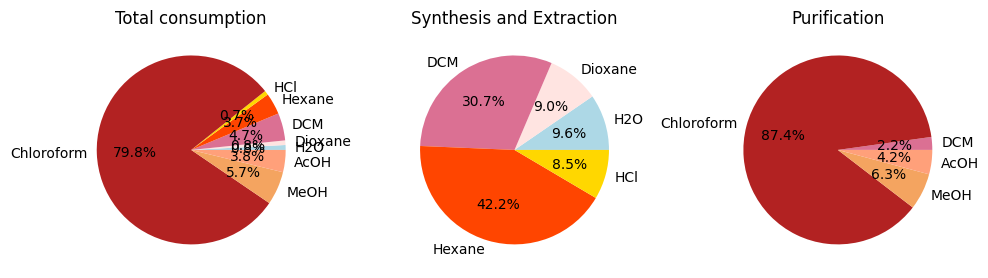

In [ ]:
# Solvent composition
labels1 = ['H2O', 'Dioxane', 'DCM', 'Hexane', 'HCl', 'Chloroform', 'MeOH', 'AcOH']
sizes1 = [5500, 5165, 30894.2, 24200, 4873.25, 526063, 37717.6, 25023.8]

labels2 = ['H2O', 'Dioxane', 'DCM', 'Hexane', 'HCl']
sizes2 = [5500, 5165, 17644.7, 24200, 4873.25]

labels3 = ['DCM', 'Chloroform', 'MeOH', 'AcOH']
sizes3 = [13250, 526063, 37717.6, 25023.8]

# Creating Multiple Subplots for Pie Charts
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 8))

# Pie Chart 1
axes[0].pie(sizes1, labels=labels1, autopct='%1.1f%%', colors=['lightblue', 'mistyrose', 'palevioletred', 'orangered', 'gold', 'firebrick', 'sandybrown', 'lightsalmon'])
axes[0].set_title('Total consumption')

# Pie Chart 2
axes[1].pie(sizes2, labels=labels2, autopct='%1.1f%%', colors=['lightblue', 'mistyrose', 'palevioletred', 'orangered', 'gold'])
axes[1].set_title('Synthesis and Extraction')

# Pie Chart 3
axes[2].pie(sizes3, labels=labels3, autopct='%1.1f%%', colors=['palevioletred', 'firebrick', 'sandybrown', 'lightsalmon'])
axes[2].set_title('Purification')

# Adjusting layout
#plt.suptitle('Solvent consumption', fontsize=14)
plt.tight_layout()

# Show the plots
plt.show()

In [ ]:
# Hazard score
